### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [76]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [77]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [78]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [79]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [80]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [81]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [82]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [83]:
tavily.invoke("Provide me the recent AI news for Nov 29th 2025")

[{'title': 'AI News November 29 2025: The Pulse & The Pattern - YouTube',
  'url': 'https://www.youtube.com/watch?v=_bFcGKOE7HA',
  'content': 'Read the Full Analysis & Sources: https://binaryverseai.com/ai-news-november-29-2025/ The gap between theoretical research and practical',
  'score': 0.8380581},
 {'title': 'Entering a new world with robots and AI - The Journal',
  'url': 'https://www.nujournal.com/opinion/columns/2025/11/29/entering-a-new-world-with-robots-and-ai/',
  'content': 'homepage logo\n\nhomepage logo\n\n# Entering a new world with robots and AI\n\n## \n\nNov 29, 2025\n\n#### Randy Krzmarzick\n\n##### Weeds\n\n###### \n\nMy heart sank a little when I heard. We knew it was coming. Baseball will be little less human and a little more mechanical. [...] John Deere recently had an advertising campaign with this theme: “Machines that think like you do.” I sent that out to a few friends. One of them replied that my tractor would want to go to the Brewery.\n\nThis mostly ligh

In [84]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [85]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")

llm_with_tools=llm.bind_tools(tools)

In [86]:
# import json
# from langchain_groq import ChatGroq
# from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

# # 1. Load model
# llm = ChatGroq(model="llama-3.1-8b-instant")

# # 2. Bind your tools (you already have `tools`)
# llm_with_tools = llm.bind_tools(tools)

# # 3. Ask question
# result = llm_with_tools.invoke([
#     HumanMessage(content="What is the recent AI News")
# ])

# # 4. Extract tool call
# tool_call = result.additional_kwargs["tool_calls"][0]
# tool_name = tool_call["function"]["name"]
# tool_args = json.loads(tool_call["function"]["arguments"])

# # 5. Execute the tool
# tool_result = tools[tool_name].run(tool_args)

# # 6. Send tool output back to LLM
# final = llm_with_tools.invoke([
#     HumanMessage(content="What is the recent AI News"),
#     result,  # the AI tool call
#     ToolMessage(
#         content=json.dumps(tool_result),
#         tool_call_id=tool_call["id"]
#     )
# ])

# print(final.content)


In [87]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Recent AI News'},
  'id': '4gftv3g2f',
  'type': 'tool_call'}]

In [88]:
result = llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])
print(result)

content='' additional_kwargs={'tool_calls': [{'id': '1ryhpaqc6', 'function': {'arguments': '{"query":"Recent AI News"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 553, 'total_tokens': 573, 'completion_time': 0.041790698, 'prompt_time': 0.029429678, 'queue_time': 0.046237992, 'total_time': 0.071220376, 'prompt_tokens_details': {'cached_tokens': 512}}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None} id='run--f5e41d41-8993-4ae0-a838-eadf3df51c94-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Recent AI News'}, 'id': '1ryhpaqc6', 'type': 'tool_call'}] usage_metadata={'input_tokens': 553, 'output_tokens': 20, 'total_tokens': 573}


In [89]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

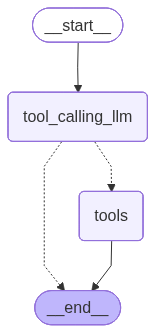

In [90]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [91]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (zgq4cy1r7)
 Call ID: zgq4cy1r7
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [92]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (z7yk2edts)
 Call ID: z7yk2edts
  Args:
    query: Recent AI news March 3rd 2025 top 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI INTELLIGENCE | Weekly Top 10 (3/14/25) - Dwealth.news", "url": "https://dwealth.news/2025/03/ai-intelligence-weekly-top-10-3-14-25/", "content": "Chinese startup Monica unveiled Manus, an autonomous AI agent capable of independently executing complex tasks without human intervention. Manus can analyze data, plan dynamically, and make decisions across various domains, marking a significant step toward artificial general intelligence. ​\n\n10. Google’s DeepMind Introduces Gemini Robotics AI Model [...] fell by 17% in 2

In [93]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (nd965cpkw)
 Call ID: nd965cpkw
  Args:
    query: Machine learning
  tavily_search_results_json (2j2f6tc9h)
 Call ID: 2j2f6tc9h
  Args:
    query: Machine learning definition
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
=============

In [94]:
messages=graph.invoke({"messages":HumanMessage(content="Who am I?")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Who am I?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (x72g4nj30)
 Call ID: x72g4nj30
  Args:
    query: your identity
================================= Tool Message =================================
Name: wikipedia

Page: Daniella Zalcman
Summary: Daniella Zalcman (born 1986) is a Vietnamese-American documentary photographer whose work often addresses the history and impact of western colonization. Her works include Signs of Your Identity, a series of portraits which documents survivors of Canadian residential schools. This exhibition has received multiple awards, including the Inge Morath Award.  The accompanying book Signs of Your Identity (2016) received the 2016 FotoEvidence Book Award. Her work is incl
